In [83]:
import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import requests


from web3 import Web3

from dotenv import load_dotenv
load_dotenv()

True

## Сбор данных

Блоки Ethereum из Google BigQuery:

```
SELECT timestamp, 
       number as height, 
       `hash`,
       size,
       gas_limit,
       gas_used,
       transaction_count,
       base_fee_per_gas
FROM `bigquery-public-data.crypto_ethereum.blocks` 
WHERE TIMESTAMP_TRUNC(timestamp, DAY) >= TIMESTAMP("2025-04-15") 
  and TIMESTAMP_TRUNC(timestamp, DAY) < TIMESTAMP("2026-04-16") 
```

In [80]:
df = pd.read_csv('data/eth_blocks_2025-04-15_2026-04-15.csv')
df

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
0,2025-12-11 23:47:59 UTC,23992805,0x27273e2e6f523edccedec299babc72c8841343049dfb...,154517,59824395,59072558,232,107248509
1,2025-12-11 10:08:23 UTC,23988743,0x8652b2712f30e65c0419c260d29c72b42816a8ef24bf...,116452,59941066,23494422,297,129667207
2,2025-12-11 13:32:23 UTC,23989754,0x4f32bf081fec9d65fc2c49c8efffe1e0e2036f8e2a27...,196812,59999829,47224397,385,111763769
3,2025-12-11 07:27:35 UTC,23987946,0x086539c9ed8b7b6f5ec4fafc2af7133f8340df1e1ec2...,51108,60058535,17217624,188,129857135
4,2025-12-11 15:48:35 UTC,23990434,0x571ac95e54986cc3630d99f32497d8f07ad5947f05ea...,143688,59882873,27927661,370,119736588
...,...,...,...,...,...,...,...,...
2617989,2025-11-28 14:00:59 UTC,23897632,0xc1d87322b51b6463ac543bdbba0eb6402628236903c7...,48350,60000000,11098802,144,77760089
2617990,2025-11-28 12:08:23 UTC,23897075,0xd8057b22a20e844395da1bd401271ce21ea4d33c6b23...,42297,60000000,11780026,193,85375569
2617991,2025-11-28 15:10:11 UTC,23897975,0x11b81f3de7e8c757cb488c6a52e371bc1229fd458cf5...,189843,60000000,32305085,355,110267057
2617992,2025-11-28 05:26:47 UTC,23895086,0x7d8ddb94323b8b2a2c7f95d2834449e858983374ae5c...,122609,60000000,51125368,246,49792442


In [81]:
df.describe()

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
count,2.617994e+06,2.617994e+06,2.617994e+06,2.617994e+06,2.617994e+06,2.617994e+06
mean,2.357966e+07,1.247178e+05,4.839512e+07,2.450420e+07,2.421711e+02,8.472808e+08
std,7.557499e+05,7.276937e+04,9.824617e+06,1.240824e+07,1.369606e+02,3.702166e+09
min,2.227067e+07,1.163000e+03,3.523384e+07,0.000000e+00,0.000000e+00,8.703865e+06
25%,2.292517e+07,7.980900e+04,3.610543e+07,1.622436e+07,1.630000e+02,8.135616e+07
50%,2.357966e+07,1.099920e+05,4.500000e+07,2.205721e+07,2.160000e+02,2.309768e+08
75%,2.423416e+07,1.528910e+05,6.000000e+07,3.063584e+07,2.880000e+02,6.716429e+08
max,2.488866e+07,1.641564e+06,6.011724e+07,6.005850e+07,2.753000e+03,5.472282e+11


In [82]:
print("=" * 60)
print("SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMNS & DTYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("MEMORY USAGE")
print("=" * 60)
print(df.memory_usage(deep=True).to_string())
print(f"\nTotal: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print(missing_df[missing_df["count"] > 0] if missing_df["count"].sum() > 0 else "No missing values")

print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)
print(f"Duplicate rows: {df.duplicated().sum():,}")


print("\n" + "=" * 60)
print("UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col}: {n:,} unique")

SHAPE
Rows: 2,617,994  |  Columns: 8

COLUMNS & DTYPES
timestamp            object
height                int64
hash                 object
size                  int64
gas_limit             int64
gas_used              int64
transaction_count     int64
base_fee_per_gas      int64
dtype: object

MEMORY USAGE
Index                      132
timestamp            209439520
height                20943952
hash                 322013262
size                  20943952
gas_limit             20943952
gas_used              20943952
transaction_count     20943952
base_fee_per_gas      20943952

Total: 626.68 MB

MISSING VALUES
No missing values

DUPLICATES
Duplicate rows: 0

UNIQUE VALUES PER COLUMN
  timestamp: 2,617,994 unique
  height: 2,617,994 unique
  hash: 2,617,994 unique
  size: 336,719 unique
  gas_limit: 52,083 unique
  gas_used: 2,510,511 unique
  transaction_count: 2,139 unique
  base_fee_per_gas: 2,610,927 unique


### Цена ETH для обогащения датасета

In [92]:
# coingecko

API_KEY = os.getenv("COINGECKO_API_KEY")

url = "https://api.coingecko.com/api/v3/simple/price"

In [ ]:
params = {
    "ids": "ethereum",
    "vs_currencies": "usd"
}

headers = {
    "x-cg-demo-api-key": API_KEY
}

response = requests.get(url, params=params, headers=headers)

data = response.json()

eth_price = data["ethereum"]["usd"]

print(f"Current ETH price: ${eth_price}")

Current ETH price: $2075.69


In [ ]:
start_date = datetime(2025, 4, 13)
end_date = datetime(2026, 4, 17)

chunk_days = 90

rows = []

current_start = start_date

while current_start < end_date:

    current_end = min(current_start + timedelta(days=chunk_days), end_date)
    print(f"Fetching data from {current_start.date()} to {current_end.date()}...")
    
    params = {
        "vs_currency": "usd",
        "from": int(current_start.timestamp()),
        "to": int(current_end.timestamp())
    }

    response = requests.get(BASE_URL, params=params, headers=headers)
    data = response.json()

    prices = data["prices"]
    market_caps = data["market_caps"]
    volumes = data["total_volumes"]

    for i in range(len(prices)):
        timestamp = prices[i][0]

        rows.append({
            "timestamp": timestamp,
            "datetime": pd.to_datetime(timestamp, unit="ms"),
            "price": prices[i][1],
            "market_cap": market_caps[i][1],
            "volume": volumes[i][1]
        })

    print(f"Loaded {current_start.date()} → {current_end.date()}")

    current_start = current_end
    time.sleep(1)

df = pd.DataFrame(rows)

df = df.sort_values("datetime").reset_index(drop=True)

df.head()

Fetching data from 2025-03-06 to 2025-06-04...
Loaded 2025-03-06 → 2025-06-04
Fetching data from 2025-06-04 to 2025-09-02...
Loaded 2025-06-04 → 2025-09-02
Fetching data from 2025-09-02 to 2025-12-01...
Loaded 2025-09-02 → 2025-12-01
Fetching data from 2025-12-01 to 2026-03-01...
Loaded 2025-12-01 → 2026-03-01
Fetching data from 2026-03-01 to 2026-03-05...
Loaded 2026-03-01 → 2026-03-05
       timestamp                datetime        price    market_cap  \
0  1741208564423 2025-03-05 21:02:44.423  2230.584518  2.693445e+11   
1  1741212295383 2025-03-05 22:04:55.383  2236.766636  2.697674e+11   
2  1741215784773 2025-03-05 23:03:04.773  2239.435736  2.699957e+11   
3  1741219748187 2025-03-06 00:09:08.187  2244.935432  2.706242e+11   
4  1741223086191 2025-03-06 01:04:46.191  2239.385254  2.699733e+11   

         volume  
0  2.335307e+10  
1  2.253690e+10  
2  2.218404e+10  
3  2.222023e+10  
4  2.234494e+10  


In [17]:
df

,timestamp,datetime,price,market_cap,volume
0,1741208564423,2025-03-05 21:02:44.423,2230.584518,2.693445e+11,2.335307e+10
1,1741212295383,2025-03-05 22:04:55.383,2236.766636,2.697674e+11,2.253690e+10
2,1741215784773,2025-03-05 23:03:04.773,2239.435736,2.699957e+11,2.218404e+10
3,1741219748187,2025-03-06 00:09:08.187,2244.935432,2.706242e+11,2.222023e+10
4,1741223086191,2025-03-06 01:04:46.191,2239.385254,2.699733e+11,2.234494e+10
...,...,...,...,...,...
8731,1772640207826,2026-03-04 16:03:27.826,2150.392505,2.588748e+11,3.143937e+10
8732,1772643799382,2026-03-04 17:03:19.382,2143.077149,2.586854e+11,3.120427e+10
8733,1772647410540,2026-03-04 18:03:30.540,2147.037185,2.592250e+11,3.166291e+10
8734,1772650975057,2026-03-04 19:02:55.057,2162.208620,2.609615e+11,3.140737e+10


In [ ]:
BASE_URL = "https://data-api.coindesk.com/index/cc/v1/historical/minutes"
COINDESK_API_KEY = os.getenv("COINDESK_API_KEY")

headers = {
    "Authorization": f"Apikey {COINDESK_API_KEY}"
}

market = "cadli"
instrument = "ETH-USD"

start_date = datetime(2025, 4, 14)
end_date = datetime(2026, 4, 17)

to_ts = int(end_date.timestamp())

limit = 2000

# rows = []

while True:

    params = {
        "market": market,
        "instrument": instrument,
        "limit": limit,
        "to_ts": to_ts,
        "groups": "OHLC,VOLUME",
        "aggregate": 1
    }

    r = requests.get(BASE_URL, params=params, headers=headers)
    data = r.json()

    batch = data["Data"]

    if not batch:
        break

    rows.extend(batch)

    oldest_ts = batch[0]["TIMESTAMP"]

    print("Downloaded until:", datetime.fromtimestamp(oldest_ts))

    if oldest_ts <= int(start_date.timestamp()):
        break
    to_ts = oldest_ts - 60

    time.sleep(1)

In [91]:
df = pd.DataFrame(rows)
df["datetime"] = pd.to_datetime(df["TIMESTAMP"], unit="s")
df = df.sort_values("datetime")

df = df.rename(columns={
    "OPEN": "open",
    "HIGH": "high",
    "LOW": "low",
    "CLOSE": "close",
    "VOLUME": "volume"
})

df = df.drop_duplicates(subset=["TIMESTAMP"])
df

,UNIT,TIMESTAMP,open,high,low,close,volume,QUOTE_VOLUME,VOLUME_TOP_TIER,QUOTE_VOLUME_TOP_TIER,VOLUME_DIRECT,QUOTE_VOLUME_DIRECT,VOLUME_TOP_TIER_DIRECT,QUOTE_VOLUME_TOP_TIER_DIRECT,datetime
166000,MINUTE,1766293380,2975.110716,2975.246945,2975.002261,2975.244334,231.222103,6.879144e+05,46.647438,1.388437e+05,8.829780,26265.308731,8.727390,25958.638941,2025-12-21 05:03:00
166001,MINUTE,1766293440,2975.244334,2975.309781,2974.539671,2974.539793,378.996148,1.127403e+06,126.671937,3.768329e+05,16.265526,48378.533033,16.128430,47968.437035,2025-12-21 05:04:00
166002,MINUTE,1766293500,2974.539793,2976.070536,2974.539568,2976.070200,328.905811,9.788077e+05,156.212479,4.650406e+05,49.138454,146162.387996,49.073914,145970.431823,2025-12-21 05:05:00
166003,MINUTE,1766293560,2976.070200,2976.091592,2975.215506,2975.393731,497.966924,1.481798e+06,209.456494,6.233797e+05,16.485552,49040.091116,16.455042,48948.407184,2025-12-21 05:06:00
166004,MINUTE,1766293620,2975.393731,2975.709512,2975.117529,2975.623698,428.220813,1.273878e+06,124.626800,3.707593e+05,17.485812,52002.090472,17.351046,51599.011008,2025-12-21 05:07:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,MINUTE,1776372960,2348.273880,2349.231203,2348.246726,2348.750841,820.876028,1.928181e+06,384.685157,9.036218e+05,77.392153,181824.304263,77.213193,181403.799793,2026-04-16 20:56:00
1996,MINUTE,1776373020,2348.750841,2350.121545,2348.742061,2350.092517,790.735872,1.857596e+06,316.991592,7.447421e+05,39.417988,92631.146619,39.184068,92081.202798,2026-04-16 20:57:00
1997,MINUTE,1776373080,2350.092517,2350.835093,2350.090775,2350.606920,1446.222961,3.399611e+06,682.632807,1.604733e+06,93.014594,218684.195406,89.722034,210947.712405,2026-04-16 20:58:00
1998,MINUTE,1776373140,2350.606920,2350.626563,2350.330366,2350.361710,1734.835391,4.077958e+06,631.004432,1.483291e+06,112.342241,264101.206433,110.295981,259265.263707,2026-04-16 20:59:00


In [ ]:
df = df.sort_values("datetime").reset_index(drop=True)

# вычисляем разницу между соседними часами
df["diff_minutes"] = df["datetime"].diff().dt.total_seconds() / 60

# проверяем, есть ли пропуски
missing_hours = df[df["diff_minutes"] != 1]

if missing_hours.empty:
    print("Все часы на месте! Пропусков нет.")
else:
    print("Есть пропуски часов:")
    print(missing_hours[["datetime", "diff_minutes"]])

Есть пропуски часов:
             datetime  diff_minutes
0 2024-12-31 09:08:00           NaN


### Обогащение датасета с блоками ценой ETH

In [111]:
blocks = pd.read_csv("data/eth_blocks_2025-04-15_2026-04-15.csv")
blocks

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
0,2025-12-11 23:47:59 UTC,23992805,0x27273e2e6f523edccedec299babc72c8841343049dfb...,154517,59824395,59072558,232,107248509
1,2025-12-11 10:08:23 UTC,23988743,0x8652b2712f30e65c0419c260d29c72b42816a8ef24bf...,116452,59941066,23494422,297,129667207
2,2025-12-11 13:32:23 UTC,23989754,0x4f32bf081fec9d65fc2c49c8efffe1e0e2036f8e2a27...,196812,59999829,47224397,385,111763769
3,2025-12-11 07:27:35 UTC,23987946,0x086539c9ed8b7b6f5ec4fafc2af7133f8340df1e1ec2...,51108,60058535,17217624,188,129857135
4,2025-12-11 15:48:35 UTC,23990434,0x571ac95e54986cc3630d99f32497d8f07ad5947f05ea...,143688,59882873,27927661,370,119736588
...,...,...,...,...,...,...,...,...
2617989,2025-11-28 14:00:59 UTC,23897632,0xc1d87322b51b6463ac543bdbba0eb6402628236903c7...,48350,60000000,11098802,144,77760089
2617990,2025-11-28 12:08:23 UTC,23897075,0xd8057b22a20e844395da1bd401271ce21ea4d33c6b23...,42297,60000000,11780026,193,85375569
2617991,2025-11-28 15:10:11 UTC,23897975,0x11b81f3de7e8c757cb488c6a52e371bc1229fd458cf5...,189843,60000000,32305085,355,110267057
2617992,2025-11-28 05:26:47 UTC,23895086,0x7d8ddb94323b8b2a2c7f95d2834449e858983374ae5c...,122609,60000000,51125368,246,49792442


In [112]:
eth_prices = pd.read_csv("data/eth_minutes_2025_2026_april.csv")
eth_prices

,UNIT,TIMESTAMP,open,high,low,close,volume,QUOTE_VOLUME,VOLUME_TOP_TIER,QUOTE_VOLUME_TOP_TIER,VOLUME_DIRECT,QUOTE_VOLUME_DIRECT,VOLUME_TOP_TIER_DIRECT,QUOTE_VOLUME_TOP_TIER_DIRECT,datetime
0,MINUTE,1735636080,3378.569323,3380.485797,3378.217773,3380.465130,1767.621519,5.974709e+06,969.995245,3.278723e+06,88.282421,298298.946808,87.683491,296273.130839,2024-12-31 09:08:00
1,MINUTE,1735636140,3380.465130,3382.087644,3379.523548,3381.908966,2500.374313,8.453734e+06,1622.858775,5.487008e+06,133.230708,450299.577347,132.825178,448927.966293,2024-12-31 09:09:00
2,MINUTE,1735636200,3381.908966,3383.238625,3381.428658,3382.847440,2221.012152,7.513716e+06,1247.153641,4.219135e+06,188.263742,636652.513877,184.458903,623698.905942,2024-12-31 09:10:00
3,MINUTE,1735636260,3382.847440,3383.516298,3382.149028,3382.240800,1515.060300,5.125635e+06,867.835997,2.936108e+06,85.229725,288205.770504,85.036495,287551.856548,2024-12-31 09:11:00
4,MINUTE,1735636320,3382.240800,3383.575566,3381.438189,3381.591191,1391.147431,4.706566e+06,819.917387,2.773771e+06,78.714229,266118.741873,78.559561,265595.298606,2024-12-31 09:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678948,MINUTE,1776372960,2348.273880,2349.231203,2348.246726,2348.750841,820.876028,1.928181e+06,384.685157,9.036218e+05,77.392153,181824.304263,77.213193,181403.799793,2026-04-16 20:56:00
678949,MINUTE,1776373020,2348.750841,2350.121545,2348.742061,2350.092517,790.735872,1.857596e+06,316.991592,7.447421e+05,39.417988,92631.146619,39.184068,92081.202798,2026-04-16 20:57:00
678950,MINUTE,1776373080,2350.092517,2350.835093,2350.090775,2350.606920,1446.222961,3.399611e+06,682.632807,1.604733e+06,93.014594,218684.195406,89.722034,210947.712405,2026-04-16 20:58:00
678951,MINUTE,1776373140,2350.606920,2350.626563,2350.330366,2350.361710,1734.835391,4.077958e+06,631.004432,1.483291e+06,112.342241,264101.206433,110.295981,259265.263707,2026-04-16 20:59:00


In [113]:
blocks.columns

Index(['timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas'],
      dtype='object')

In [114]:
eth_prices.columns

Index(['UNIT', 'TIMESTAMP', 'open', 'high', 'low', 'close', 'volume',
       'QUOTE_VOLUME', 'VOLUME_TOP_TIER', 'QUOTE_VOLUME_TOP_TIER',
       'VOLUME_DIRECT', 'QUOTE_VOLUME_DIRECT', 'VOLUME_TOP_TIER_DIRECT',
       'QUOTE_VOLUME_TOP_TIER_DIRECT', 'datetime'],
      dtype='object')

In [115]:
blocks['timestamp'] = pd.to_datetime(blocks['timestamp']).dt.tz_localize(None) # убираем timezone, чтобы не было проблем при объединении с ценами
eth_prices['datetime'] = pd.to_datetime(eth_prices['datetime']).dt.tz_localize(None)

In [116]:
blocks = blocks.sort_values('timestamp')
eth_prices = eth_prices.sort_values('datetime')

In [117]:
blocks_with_price = pd.merge_asof(
    blocks,
    eth_prices[['datetime', 'close']],
    left_on='timestamp',
    right_on='datetime',
    direction='backward' # чтобы избежать утечки будущего, всегда берем последнее известное значение цены
)

In [118]:
blocks_with_price.rename(columns={"close": "last_eth_price"}, inplace=True)

In [128]:
blocks_with_price.drop(columns=['datetime'], inplace=True)

In [145]:
blocks_with_price['timestamp'] = pd.to_datetime(blocks_with_price['timestamp'])

In [147]:
blocks_with_price.to_csv("data/blocks_with_price_until_april.csv", index=False)

In [131]:
blocks_with_price.columns

Index(['timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price'],
      dtype='object')

In [120]:
blocks_with_price['last_eth_price'].isna().sum()

np.int64(0)

In [132]:
blocks_with_price

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price
0,2025-04-15 00:00:11,22270668,0x6052396369322656b8bf2b800feb724e24eed1562a24...,74471,35929725,30809730,244,378221989,1624.928957
1,2025-04-15 00:00:23,22270669,0xadefdff6845c6c067030916e476dca253e5354558f4a...,102234,35894639,22815810,223,412025557,1624.928957
2,2025-04-15 00:00:35,22270670,0x4e64fff39a2343ebae259a98baad38910ea21c47488f...,16385,35859587,4470024,33,425996604,1624.928957
3,2025-04-15 00:00:47,22270671,0x50c68d1321a3c711b5ce5d876936ebce080f02f4e96a...,125361,35824569,27135078,287,386022524,1624.928957
4,2025-04-15 00:00:59,22270672,0xbe8e833f6fd67eb8cc359cba8ee7a35cbc77171327a7...,60138,35789586,12797878,126,410867249,1624.928957
...,...,...,...,...,...,...,...,...,...
2617989,2026-04-15 23:59:11,24888657,0xcb609d2ba561ad80946926aa7ef6c1a940a2d76f719b...,166008,60000000,32542067,239,46880934,2360.237638
2617990,2026-04-15 23:59:23,24888658,0xf688f46733b5553e685dcd3103bce7fae2061cebe0ac...,48152,60000000,9933771,98,47377494,2360.237638
2617991,2026-04-15 23:59:35,24888659,0xb952f622494d876910a00f1cccd3b5b118a2d63f4989...,112172,59941408,21864727,185,43416296,2360.237638
2617992,2026-04-15 23:59:47,24888660,0x262f6bb2ae0ae642a0ba76b160adb698553ae09b7e20...,151065,59882873,28125264,220,41948482,2360.237638


In [122]:
blocks_with_price.columns

Index(['timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'datetime', 'last_eth_price'],
      dtype='object')

# Feature engineering

Cоздадим несколько горизонтов прогнозирования.
В Ethereum блок  = 12 сек.

| горизонт   | блоков |
| ---------- | ------ |
| next block | 1      |
| 10 минут   | ~50    |
| 1 час      | ~300   |
| 1 день     | ~7200  |
| 1 неделя   | ~50400 |



| горизонт   | что модель учит     |
| ---------- | ------------------- |
| next block | находит формулу     |
| 10m        | краткосрочный тренд |
| 1h         | инерцию             |
| 1d         | дневной режим       |
| 1w         | недельный режим     |



In [148]:
blocks_with_price = pd.read_csv('data/blocks_with_price_until_april.csv')

### Общие признаки для всех горизонтов

In [149]:
df = blocks_with_price.copy()

# df["target_next_block"] = df["base_fee_per_gas"].shift(-1)
# df["target_10m"] = df["base_fee_per_gas"].shift(-int(60/12*10))
# df["target_1h"] = df["base_fee_per_gas"].shift(-int(60/12*60))
# df["target_1d"] = df["base_fee_per_gas"].shift(-int(60/12*60*24))
# df["target_1w"] = df["base_fee_per_gas"].shift(-int(60/12*60*24*7))

Основные сетевые признаки (network state)
Base fee напрямую зависит от заполненности блока (EIP-1559). Base fee увеличивается если: gas_used > gas_limit / 2

In [150]:
df["block_utilization"] = df["gas_used"] / df["gas_limit"]

In [151]:
# давление на base fee.
df["gas_pressure"] = df["gas_used"] - df["gas_limit"] / 2

transactions density - proxy для типа транзакций (DeFi / swaps / NFT).

In [152]:
df["tx_per_gas"] = df["transaction_count"] / df["gas_used"]

#### Time features

В Ethereum активность может зависеть от времени суток

In [154]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [155]:
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

Сохраним датасет с общими для всех моделей признаками

In [ ]:
df.drop('hash', axis=1, inplace=True)  # хэш блока бесполезен как признак

In [161]:
df.to_parquet("data/common_features.parquet.gzip", compression="gzip")

In [162]:
file_size_bytes = os.path.getsize('data/common_features.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер сжатого файла: {file_size_mb:.2f} МБ')

Размер сжатого файла: 108.35 МБ


In [158]:
df

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,month,day,hour,day_of_week,is_weekend
0,2025-04-15 00:00:11,22270668,0x6052396369322656b8bf2b800feb724e24eed1562a24...,74471,35929725,30809730,244,378221989,1624.928957,0.857500,12844867.5,0.000008,4,4,0,1,0
1,2025-04-15 00:00:23,22270669,0xadefdff6845c6c067030916e476dca253e5354558f4a...,102234,35894639,22815810,223,412025557,1624.928957,0.635633,4868490.5,0.000010,4,4,0,1,0
2,2025-04-15 00:00:35,22270670,0x4e64fff39a2343ebae259a98baad38910ea21c47488f...,16385,35859587,4470024,33,425996604,1624.928957,0.124654,-13459769.5,0.000007,4,4,0,1,0
3,2025-04-15 00:00:47,22270671,0x50c68d1321a3c711b5ce5d876936ebce080f02f4e96a...,125361,35824569,27135078,287,386022524,1624.928957,0.757443,9222793.5,0.000011,4,4,0,1,0
4,2025-04-15 00:00:59,22270672,0xbe8e833f6fd67eb8cc359cba8ee7a35cbc77171327a7...,60138,35789586,12797878,126,410867249,1624.928957,0.357587,-5096915.0,0.000010,4,4,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617989,2026-04-15 23:59:11,24888657,0xcb609d2ba561ad80946926aa7ef6c1a940a2d76f719b...,166008,60000000,32542067,239,46880934,2360.237638,0.542368,2542067.0,0.000007,4,4,23,2,0
2617990,2026-04-15 23:59:23,24888658,0xf688f46733b5553e685dcd3103bce7fae2061cebe0ac...,48152,60000000,9933771,98,47377494,2360.237638,0.165563,-20066229.0,0.000010,4,4,23,2,0
2617991,2026-04-15 23:59:35,24888659,0xb952f622494d876910a00f1cccd3b5b118a2d63f4989...,112172,59941408,21864727,185,43416296,2360.237638,0.364768,-8105977.0,0.000008,4,4,23,2,0
2617992,2026-04-15 23:59:47,24888660,0x262f6bb2ae0ae642a0ba76b160adb698553ae09b7e20...,151065,59882873,28125264,220,41948482,2360.237638,0.469671,-1816172.5,0.000008,4,4,23,2,0


### Feature engineering для модели на следующий блок сети

In [177]:
df_1block = pd.read_parquet("data/common_features.parquet.gzip")
df_1block.sort_values('height', ascending=True, inplace=True)

In [178]:
df_1block

,timestamp,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,month,day,hour,day_of_week,is_weekend
0,2025-04-15 00:00:11,22270668,74471,35929725,30809730,244,378221989,1624.928957,0.857500,12844867.5,0.000008,4,4,0,1,0
1,2025-04-15 00:00:23,22270669,102234,35894639,22815810,223,412025557,1624.928957,0.635633,4868490.5,0.000010,4,4,0,1,0
2,2025-04-15 00:00:35,22270670,16385,35859587,4470024,33,425996604,1624.928957,0.124654,-13459769.5,0.000007,4,4,0,1,0
3,2025-04-15 00:00:47,22270671,125361,35824569,27135078,287,386022524,1624.928957,0.757443,9222793.5,0.000011,4,4,0,1,0
4,2025-04-15 00:00:59,22270672,60138,35789586,12797878,126,410867249,1624.928957,0.357587,-5096915.0,0.000010,4,4,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617989,2026-04-15 23:59:11,24888657,166008,60000000,32542067,239,46880934,2360.237638,0.542368,2542067.0,0.000007,4,4,23,2,0
2617990,2026-04-15 23:59:23,24888658,48152,60000000,9933771,98,47377494,2360.237638,0.165563,-20066229.0,0.000010,4,4,23,2,0
2617991,2026-04-15 23:59:35,24888659,112172,59941408,21864727,185,43416296,2360.237638,0.364768,-8105977.0,0.000008,4,4,23,2,0
2617992,2026-04-15 23:59:47,24888660,151065,59882873,28125264,220,41948482,2360.237638,0.469671,-1816172.5,0.000008,4,4,23,2,0


#### Лаги

лаги base fee (gas fees имеют сильную автокорреляцию.)

In [180]:
for lag in [1,2,3,5,10,20,50,100,300]:
    df_1block[f"base_fee_lag_{lag}"] = df_1block["base_fee_per_gas"].shift(lag)

лаги utilization (сеть имеет инерцию загрузки)

In [181]:
for lag in [1,2,3,5,10,20]:
     df_1block[f"utilization_lag_{lag}"] = df_1block["block_utilization"].shift(lag)

#### Rolling признаки (тренды)

агрегаты на окнах:
1. rolling mean - покажет тренд комиссии
2. volatility - всплески комиссий часто происходят после роста волатильности
3. rolling utilization - отражает нагрузку сети

In [182]:
windows = [5, 20, 50, 300]

for w in windows:
    df_1block[f"base_fee_ma_{w}"] = df_1block["base_fee_per_gas"].rolling(w).mean()

In [183]:
for w in [20, 50, 300]:
    df_1block[f"base_fee_vol_{w}"] = df_1block["base_fee_per_gas"].rolling(w).std()

In [184]:
for w in [5, 20, 50]:
    df_1block[f"utilization_ma_{w}"] = df_1block["block_utilization"].rolling(w).mean()


#### ETH price признаки

Gas usage коррелирует с активностью рынка.

price returns - сильные движения цены → рост DeFi активности.

In [185]:
df_1block["eth_return_1m"] = df_1block["last_eth_price"].pct_change(5)
df_1block["eth_return_10m"] = df_1block["last_eth_price"].pct_change(50)
df_1block["eth_return_1h"] = df_1block["last_eth_price"].pct_change(300)

price volatility - волатильность → больше трейдинга → больше gas.

In [186]:
df_1block["eth_volatility_1h"] = df_1block["last_eth_price"].rolling(300).std()

cyclical encoding - для отслеживания суточных паттернов

In [187]:
df_1block["hour_sin"] = np.sin(2*np.pi*df_1block["hour"]/24)
df_1block["hour_cos"] = np.cos(2*np.pi*df_1block["hour"]/24)

#### Признаки скорости изменения базовой комиссии

Всплески могут иметь momentum

In [188]:
df_1block["base_fee_change_1"] = df_1block["base_fee_per_gas"].pct_change()
df_1block["base_fee_change_10"] = df_1block["base_fee_per_gas"].pct_change(10)
df_1block["base_fee_change_50"] = df_1block["base_fee_per_gas"].pct_change(50)

#### Признаки роста блоков

внезапный сетевой спрос

In [189]:
df_1block["gas_used_change"] = df_1block["gas_used"].pct_change()
df_1block["tx_change"] = df_1block["transaction_count"].pct_change()

Итоговый датасет содержит примерно такие категории признаков:

- network metrics
- lag features
- rolling statistics
- price signals
- temporal features

Целевая переменная - base_fee_per_gas в следущем блоке

In [ ]:
df_1block["target"] = df_1block["base_fee_per_gas"].shift(-1)

In [201]:
df_1block

,timestamp,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,month,day,hour,day_of_week,is_weekend,base_fee_lag_1,base_fee_lag_2,base_fee_lag_3,base_fee_lag_5,base_fee_lag_10,base_fee_lag_20,base_fee_lag_50,base_fee_lag_100,base_fee_lag_300,utilization_lag_1,utilization_lag_2,utilization_lag_3,utilization_lag_5,utilization_lag_10,utilization_lag_20,base_fee_ma_5,base_fee_ma_20,base_fee_ma_50,base_fee_ma_300,base_fee_vol_20,base_fee_vol_50,base_fee_vol_300,utilization_ma_5,utilization_ma_20,utilization_ma_50,eth_return_1m,eth_return_10m,eth_return_1h,eth_volatility_1h,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change,target
300,2025-04-15 01:00:35,22270968,76207,35929725,15692496,187,376574486,1630.546895,0.436755,-2272366.5,0.000012,4,4,1,1,0,385837910.0,358714438.0,384515482.0,428412343.0,373988995.0,392992675.0,379242302.0,348478549.0,378221989.0,0.403966,0.802452,0.231599,0.311165,0.450860,0.750167,382765974.4,3.869391e+08,3.847560e+08,3.859382e+08,1.820477e+07,2.087994e+07,2.753209e+07,0.428560,0.481973,0.512815,-0.000543,0.000883,0.003457,4.652267,0.258819,0.965926,-0.024009,0.006913,-0.007035,0.080114,0.068571,370620398.0
301,2025-04-15 01:00:47,22270969,57619,35964811,12104936,157,370620398,1630.546895,0.336577,-5877469.5,0.000013,4,4,1,1,0,376574486.0,385837910.0,358714438.0,408187556.0,369394533.0,417571121.0,351836400.0,391991548.0,412025557.0,0.436755,0.403966,0.802452,0.268027,0.767825,0.103295,375252542.8,3.845915e+08,3.851317e+08,3.858002e+08,1.703652e+07,2.043990e+07,2.750464e+07,0.442270,0.493637,0.500134,-0.000543,0.000883,0.003457,4.654736,0.258819,0.965926,-0.015811,0.003319,0.053388,-0.228616,-0.160428,355478445.0
302,2025-04-15 01:00:59,22270970,76242,35999931,31371907,179,355478445,1630.546895,0.871444,13371941.5,0.000006,4,4,1,1,0,370620398.0,376574486.0,385837910.0,384515482.0,394127774.0,376158007.0,393235738.0,364987448.0,425996604.0,0.336577,0.436755,0.403966,0.231599,0.613672,0.594426,369445135.4,3.835575e+08,3.843765e+08,3.855651e+08,1.816544e+07,2.082816e+07,2.746127e+07,0.570239,0.507488,0.507722,-0.000543,0.000883,0.003457,4.657128,0.258819,0.965926,-0.040856,-0.098063,-0.096017,1.591662,0.140127,388488489.0
303,2025-04-15 01:01:11,22270971,104498,36000000,19096262,175,388488489,1629.931761,0.530452,1096262.0,0.000009,4,4,1,1,0,355478445.0,370620398.0,376574486.0,358714438.0,405328097.0,385037794.0,392451353.0,405897987.0,386022524.0,0.871444,0.336577,0.436755,0.802452,0.391139,0.220989,375399945.6,3.837301e+08,3.842973e+08,3.855734e+08,1.819660e+07,2.080434e+07,2.746177e+07,0.515839,0.522961,0.512554,-0.000377,0.000506,0.003079,4.658089,0.258819,0.965926,0.092861,-0.041546,-0.010098,-0.391294,-0.022346,391446024.0
304,2025-04-15 01:01:23,22270972,52046,36000000,11343043,132,391446024,1629.931761,0.315085,-6656957.0,0.000012,4,4,1,1,0,388488489.0,355478445.0,370620398.0,385837910.0,394296966.0,358180350.0,371734155.0,405737666.0,410867249.0,0.530452,0.871444,0.336577,0.403966,0.846088,0.938558,376521568.4,3.853934e+08,3.846915e+08,3.855086e+08,1.723312e+07,2.074810e+07,2.742481e+07,0.498062,0.491787,0.513623,-0.000377,0.000506,0.003079,4.658990,0.258819,0.965926,0.007613,-0.007230,0.053027,-0.406007,-0.245714,373349918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617988,2026-04-15 23:58:59,24888656,212727,60000000,48632923,180,43503449,2359.465056,0.810549,18632923.0,0.000004,4,4,23,2,0,42229896.0,41331207.0,42716860.0,38324380.0,39866674.0,39405862.0,40427173.0,46488222.0,45708387.0,0.620631,0.586974,0.370248,0.998324,0.219526,0.655740,42576055.8,4.072177e+07,4.035764e+07,4.512233e+07,2.142582e+06,2.167797e+06,4.333873e+06,0.570589,0.536091,0.528698,-0.000072,0.001479,-0.002230,3.425364,-0.258819,0.9659

In [192]:
df_1block.columns

Index(['timestamp', 'height', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'block_utilization', 'gas_pressure', 'tx_per_gas', 'month', 'day',
       'hour', 'day_of_week', 'is_weekend', 'base_fee_lag_1', 'base_fee_lag_2',
       'base_fee_lag_3', 'base_fee_lag_5', 'base_fee_lag_10',
       'base_fee_lag_20', 'base_fee_lag_50', 'base_fee_lag_100',
       'base_fee_lag_300', 'utilization_lag_1', 'utilization_lag_2',
       'utilization_lag_3', 'utilization_lag_5', 'utilization_lag_10',
       'utilization_lag_20', 'base_fee_ma_5', 'base_fee_ma_20',
       'base_fee_ma_50', 'base_fee_ma_300', 'base_fee_vol_20',
       'base_fee_vol_50', 'base_fee_vol_300', 'utilization_ma_5',
       'utilization_ma_20', 'utilization_ma_50', 'eth_return_1m',
       'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h', 'hour_sin',
       'hour_cos', 'base_fee_change_1', 'base_fee_change_10',
       'base_fee_change_50', 'gas_used_change', 'tx_ch

In [194]:
df_1block.isna().sum()

timestamp                0
height                   0
size                     0
gas_limit                0
gas_used                 0
transaction_count        0
base_fee_per_gas         0
last_eth_price           0
block_utilization        0
gas_pressure             0
tx_per_gas            1378
month                    0
day                      0
hour                     0
day_of_week              0
is_weekend               0
base_fee_lag_1           1
base_fee_lag_2           2
base_fee_lag_3           3
base_fee_lag_5           5
base_fee_lag_10         10
base_fee_lag_20         20
base_fee_lag_50         50
base_fee_lag_100       100
base_fee_lag_300       300
utilization_lag_1        1
utilization_lag_2        2
utilization_lag_3        3
utilization_lag_5        5
utilization_lag_10      10
utilization_lag_20      20
base_fee_ma_5            4
base_fee_ma_20          19
base_fee_ma_50          49
base_fee_ma_300        299
base_fee_vol_20         19
base_fee_vol_50         49
b

Удалим все NA, тк их мало

In [195]:
df_1block = df_1block.dropna()

In [197]:
len(df_1block[np.isinf(df_1block).any(axis=1)]) # есть строки с inf вместо значения, получились после деления на 0

1376

In [198]:
df_1block.columns[np.isinf(df_1block).any()]

Index(['gas_used_change', 'tx_change'], dtype='object')

gas_used_change', 'tx_change' в этих столбцах они образовались после деления на 0 в функции pct_change()
причина - деление на 0

удалим их

In [ ]:
df_1block = df_1block[~np.isinf(df).any(axis=1)]

In [203]:
df_1block.drop(columns='timestamp', inplace=True)

/var/folders/my/5sln92cn76x943r5y3s4sf240000gn/T/ipykernel_99688/1468845945.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1block.drop(columns='timestamp', inplace=True)


In [204]:
df_1block

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,month,day,hour,day_of_week,is_weekend,base_fee_lag_1,base_fee_lag_2,base_fee_lag_3,base_fee_lag_5,base_fee_lag_10,base_fee_lag_20,base_fee_lag_50,base_fee_lag_100,base_fee_lag_300,utilization_lag_1,utilization_lag_2,utilization_lag_3,utilization_lag_5,utilization_lag_10,utilization_lag_20,base_fee_ma_5,base_fee_ma_20,base_fee_ma_50,base_fee_ma_300,base_fee_vol_20,base_fee_vol_50,base_fee_vol_300,utilization_ma_5,utilization_ma_20,utilization_ma_50,eth_return_1m,eth_return_10m,eth_return_1h,eth_volatility_1h,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change,target
300,22270968,76207,35929725,15692496,187,376574486,1630.546895,0.436755,-2272366.5,0.000012,4,4,1,1,0,385837910.0,358714438.0,384515482.0,428412343.0,373988995.0,392992675.0,379242302.0,348478549.0,378221989.0,0.403966,0.802452,0.231599,0.311165,0.450860,0.750167,382765974.4,3.869391e+08,3.847560e+08,3.859382e+08,1.820477e+07,2.087994e+07,2.753209e+07,0.428560,0.481973,0.512815,-0.000543,0.000883,0.003457,4.652267,0.258819,0.965926,-0.024009,0.006913,-0.007035,0.080114,0.068571,370620398.0
301,22270969,57619,35964811,12104936,157,370620398,1630.546895,0.336577,-5877469.5,0.000013,4,4,1,1,0,376574486.0,385837910.0,358714438.0,408187556.0,369394533.0,417571121.0,351836400.0,391991548.0,412025557.0,0.436755,0.403966,0.802452,0.268027,0.767825,0.103295,375252542.8,3.845915e+08,3.851317e+08,3.858002e+08,1.703652e+07,2.043990e+07,2.750464e+07,0.442270,0.493637,0.500134,-0.000543,0.000883,0.003457,4.654736,0.258819,0.965926,-0.015811,0.003319,0.053388,-0.228616,-0.160428,355478445.0
302,22270970,76242,35999931,31371907,179,355478445,1630.546895,0.871444,13371941.5,0.000006,4,4,1,1,0,370620398.0,376574486.0,385837910.0,384515482.0,394127774.0,376158007.0,393235738.0,364987448.0,425996604.0,0.336577,0.436755,0.403966,0.231599,0.613672,0.594426,369445135.4,3.835575e+08,3.843765e+08,3.855651e+08,1.816544e+07,2.082816e+07,2.746127e+07,0.570239,0.507488,0.507722,-0.000543,0.000883,0.003457,4.657128,0.258819,0.965926,-0.040856,-0.098063,-0.096017,1.591662,0.140127,388488489.0
303,22270971,104498,36000000,19096262,175,388488489,1629.931761,0.530452,1096262.0,0.000009,4,4,1,1,0,355478445.0,370620398.0,376574486.0,358714438.0,405328097.0,385037794.0,392451353.0,405897987.0,386022524.0,0.871444,0.336577,0.436755,0.802452,0.391139,0.220989,375399945.6,3.837301e+08,3.842973e+08,3.855734e+08,1.819660e+07,2.080434e+07,2.746177e+07,0.515839,0.522961,0.512554,-0.000377,0.000506,0.003079,4.658089,0.258819,0.965926,0.092861,-0.041546,-0.010098,-0.391294,-0.022346,391446024.0
304,22270972,52046,36000000,11343043,132,391446024,1629.931761,0.315085,-6656957.0,0.000012,4,4,1,1,0,388488489.0,355478445.0,370620398.0,385837910.0,394296966.0,358180350.0,371734155.0,405737666.0,410867249.0,0.530452,0.871444,0.336577,0.403966,0.846088,0.938558,376521568.4,3.853934e+08,3.846915e+08,3.855086e+08,1.723312e+07,2.074810e+07,2.742481e+07,0.498062,0.491787,0.513623,-0.000377,0.000506,0.003079,4.658990,0.258819,0.965926,0.007613,-0.007230,0.053027,-0.406007,-0.245714,373349918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617988,24888656,212727,60000000,48632923,180,43503449,2359.465056,0.810549,18632923.0,0.000004,4,4,23,2,0,42229896.0,41331207.0,42716860.0,38324380.0,39866674.0,39405862.0,40427173.0,46488222.0,45708387.0,0.620631,0.586974,0.370248,0.998324,0.219526,0.655740,42576055.8,4.072177e+07,4.035764e+07,4.512233e+07,2.142582e+06,2.167797e+06,4.333873e+06,0.570589,0.536091,0.528698,-0.000072,0.001479,-0.002230,3.425364,-0.258819,0.965926,0.030158,0.091223,0.076094,0.306008,-0.108911,46880934.0
2617989,24888657,166008,60000000,32542067,239,46880934,2360.237638,0.54236

In [205]:
print(f'Итоговой датасет содержит {len(df_1block.columns)} колонок и {len(df_1block)} строк.')
print(f'{df_1block.columns}')

Итоговой датасет содержит 52 колонок и 2616317 строк.
Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'base_fee_lag_1', 'base_fee_lag_2', 'base_fee_lag_3',
       'base_fee_lag_5', 'base_fee_lag_10', 'base_fee_lag_20',
       'base_fee_lag_50', 'base_fee_lag_100', 'base_fee_lag_300',
       'utilization_lag_1', 'utilization_lag_2', 'utilization_lag_3',
       'utilization_lag_5', 'utilization_lag_10', 'utilization_lag_20',
       'base_fee_ma_5', 'base_fee_ma_20', 'base_fee_ma_50', 'base_fee_ma_300',
       'base_fee_vol_20', 'base_fee_vol_50', 'base_fee_vol_300',
       'utilization_ma_5', 'utilization_ma_20', 'utilization_ma_50',
       'eth_return_1m', 'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h',
       'hour_sin', 'hour_cos', 'base_fee_change_1', 'base_fee_change_10',
       'base_fee_cha

In [206]:
df_1block.to_parquet("data/models_datasets/next_block_learn.parquet.gzip", compression="gzip")

In [207]:
file_size_bytes = os.path.getsize('data/models_datasets/next_block_learn.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер сжатого файла: {file_size_mb:.2f} МБ')

Размер сжатого файла: 633.60 МБ


### Feature engineering для модели базовой комиссии через 10 минут

In [225]:
df_10m = pd.read_parquet("data/common_features.parquet.gzip")
df_10m.sort_values('height', ascending=True, inplace=True)

краткосрочный тренд + инерция

In [226]:
# лаги
for lag in [1,5,10,20,50]:
    df_10m[f"base_fee_lag_{lag}"] = df_10m["base_fee_per_gas"].shift(lag)
    df_10m[f"util_lag_{lag}"] = df_10m["block_utilization"].shift(lag)

In [227]:
# окна
for w in [10, 20, 50]:
    df_10m[f"base_fee_ma_{w}"] = df_10m["base_fee_per_gas"].rolling(w).mean()
    df_10m[f"base_fee_vol_{w}"] = df_10m["base_fee_per_gas"].rolling(w).std()

In [228]:
# momentum
df_10m["base_fee_change_5"] = df_10m["base_fee_per_gas"].pct_change(5)
df_10m["base_fee_change_20"] = df_10m["base_fee_per_gas"].pct_change(20)

In [229]:
# ETH 
df_10m["eth_return_10m"] = df_10m["last_eth_price"].pct_change(50)

Целевая переменная - базовая комиссия через 10 минут (50 блоков)

In [ ]:
df_10m["target"] = df_10m["base_fee_per_gas"].shift(-int(60/12*10))

In [237]:
df_10m = df_10m.rename(columns={"target_10m": "target"})

Удалим из датасета все строки, которые содержат NA, удалис все строки которые содержат inf, а также удалим столбец timestamp

In [231]:
len(df_10m)

2617994

In [232]:
def clean_df(df):
    return (
        df.drop(columns='timestamp')
          .replace([np.inf, -np.inf], np.nan)
          .dropna()
    )

In [233]:
df_10m = clean_df(df_10m)

In [234]:
len(df_10m)

2616516

In [239]:
df_10m.to_parquet("data/models_datasets/10_min_learn.parquet.gzip", compression="gzip")

In [240]:
print(f'Итоговой датасет содержит {len(df_10m.columns)} колонок и {len(df_10m)} строк.')
print(f'{df_10m.columns}')

Итоговой датасет содержит 35 колонок и 2616516 строк.
Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'base_fee_lag_1', 'util_lag_1', 'base_fee_lag_5',
       'util_lag_5', 'base_fee_lag_10', 'util_lag_10', 'base_fee_lag_20',
       'util_lag_20', 'base_fee_lag_50', 'util_lag_50', 'base_fee_ma_10',
       'base_fee_vol_10', 'base_fee_ma_20', 'base_fee_vol_20',
       'base_fee_ma_50', 'base_fee_vol_50', 'base_fee_change_5',
       'base_fee_change_20', 'eth_return_10m', 'target'],
      dtype='object')


In [241]:
file_size_bytes = os.path.getsize('data/models_datasets/10_min_learn.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер сжатого файла: {file_size_mb:.2f} МБ')

Размер сжатого файла: 413.61 МБ


### Feature engineering для модели базовой комиссии через 1 час

инерция + короткий тренд

In [243]:
df_1h = pd.read_parquet("data/common_features.parquet.gzip")
df_1h.sort_values('height', ascending=True, inplace=True)

Целевая переменная - базовая комиссия через 1 час (300 блоков)

In [244]:
df_1h["target"] = df_1h["base_fee_per_gas"].shift(-int(60/12*60))

In [245]:
# лаги
for lag in [1,10,50,100,300]:
    df_1h[f"base_fee_lag_{lag}"] = df_1h["base_fee_per_gas"].shift(lag)

In [246]:
# окна
for w in [50, 100, 300]:
    df_1h[f"base_fee_ma_{w}"] = df_1h["base_fee_per_gas"].rolling(w).mean()
    df_1h[f"base_fee_vol_{w}"] = df_1h["base_fee_per_gas"].rolling(w).std()

In [247]:
# utilization агрегаты
df_1h["util_ma_50"] = df_1h["block_utilization"].rolling(50).mean()
df_1h["util_ma_300"] = df_1h["block_utilization"].rolling(300).mean()

In [248]:
# ETH
df_1h["eth_return_1h"] = df_1h["last_eth_price"].pct_change(300)
df_1h["eth_vol_1h"] = df_1h["last_eth_price"].rolling(300).std()

In [249]:
df_1h = clean_df(df_1h)

In [251]:
print(f'Итоговой датасет содержит {len(df_1h.columns)} колонок и {len(df_1h)} строк.')
print(f'{df_1h.columns}')

Итоговой датасет содержит 31 колонок и 2616018 строк.
Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'target', 'base_fee_lag_1', 'base_fee_lag_10',
       'base_fee_lag_50', 'base_fee_lag_100', 'base_fee_lag_300',
       'base_fee_ma_50', 'base_fee_vol_50', 'base_fee_ma_100',
       'base_fee_vol_100', 'base_fee_ma_300', 'base_fee_vol_300', 'util_ma_50',
       'util_ma_300', 'eth_return_1h', 'eth_vol_1h'],
      dtype='object')


In [252]:
cols = [c for c in df_1h.columns if c != 'target'] + ['target']
df_1h = df_1h[cols]

In [253]:
df_1h

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,month,day,hour,day_of_week,is_weekend,base_fee_lag_1,base_fee_lag_10,base_fee_lag_50,base_fee_lag_100,base_fee_lag_300,base_fee_ma_50,base_fee_vol_50,base_fee_ma_100,base_fee_vol_100,base_fee_ma_300,base_fee_vol_300,util_ma_50,util_ma_300,eth_return_1h,eth_vol_1h,target
300,22270968,76207,35929725,15692496,187,376574486,1630.546895,0.436755,-2272366.5,0.000012,4,4,1,1,0,385837910.0,373988995.0,379242302.0,348478549.0,378221989.0,3.847560e+08,2.087994e+07,3.804057e+08,2.043310e+07,3.859382e+08,2.753209e+07,0.512815,0.508354,0.003457,4.652267,412115162.0
301,22270969,57619,35964811,12104936,157,370620398,1630.546895,0.336577,-5877469.5,0.000013,4,4,1,1,0,376574486.0,369394533.0,351836400.0,391991548.0,412025557.0,3.851317e+08,2.043990e+07,3.801920e+08,2.042245e+07,3.858002e+08,2.750464e+07,0.500134,0.507357,0.003457,4.654736,413331203.0
302,22270970,76242,35999931,31371907,179,355478445,1630.546895,0.871444,13371941.5,0.000006,4,4,1,1,0,370620398.0,394127774.0,393235738.0,364987448.0,425996604.0,3.843765e+08,2.082816e+07,3.800969e+08,2.051589e+07,3.855651e+08,2.746127e+07,0.507722,0.509846,0.003457,4.657128,369915102.0
303,22270971,104498,36000000,19096262,175,388488489,1629.931761,0.530452,1096262.0,0.000009,4,4,1,1,0,355478445.0,405328097.0,392451353.0,405897987.0,386022524.0,3.842973e+08,2.080434e+07,3.799228e+08,2.036806e+07,3.855734e+08,2.746177e+07,0.512554,0.509090,0.003079,4.658089,361679326.0
304,22270972,52046,36000000,11343043,132,391446024,1629.931761,0.315085,-6656957.0,0.000012,4,4,1,1,0,388488489.0,394296966.0,371734155.0,405737666.0,410867249.0,3.846915e+08,2.074810e+07,3.797799e+08,2.023480e+07,3.855086e+08,2.742481e+07,0.513623,0.508948,0.003079,4.658990,371558588.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617689,24888357,168578,60000000,36155997,338,42320410,2364.737850,0.602600,6155997.0,0.000009,4,4,22,2,0,45708387.0,36947713.0,39547951.0,39866489.0,46714693.0,4.562773e+07,4.856174e+06,4.446073e+07,5.157934e+06,5.861645e+07,1.881893e+07,0.502475,0.506623,0.001700,3.525484,46880934.0
2617690,24888358,133131,60000000,20831866,146,43405927,2364.007309,0.347198,-9168134.0,0.000007,4,4,22,2,0,42320410.0,41513233.0,44453717.0,37009353.0,43922760.0,4.560678e+07,4.863599e+06,4.452470e+07,5.103974e+06,5.861473e+07,1.882030e+07,0.504775,0.507091,0.001391,3.500022,47377494.0
2617691,24888359,165375,60000000,40785219,290,41747797,2364.007309,0.679754,10785219.0,0.000007,4,4,22,2,0,43405927.0,42347145.0,41477244.0,35394784.0,40701886.0,4.561219e+07,4.859059e+06,4.458823e+07,5.028160e+06,5.861822e+07,1.881707e+07,0.502997,0.506027,0.001391,3.474339,43416296.0
2617692,24888360,155847,60000000,39679468,265,43623876,2364.007309,0.661324,9679468.0,0.000007,4,4,22,2,0,41747797.0,42620966.0,44263426.0,35068510.0,45781618.0,4.559940e+07,4.863522e+06,4.467378e+07,4.936495e+06,5.861102e+07,1.882240e+07,0.496519,0.505094,0.001065,3.455453,41948482.0


In [254]:
df_1h.to_parquet("data/models_datasets/1_hour_learn.parquet.gzip", compression="gzip")

In [255]:
file_size_bytes = os.path.getsize('data/models_datasets/1_hour_learn.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер файла датасета: {file_size_mb:.2f} МБ')

Размер файла датасета: 337.32 МБ


### Feature engineering для модели базовой комиссии через 1 день

режим + дневная сезонность

In [257]:
df_1d = pd.read_parquet("data/common_features.parquet.gzip")
df_1d.sort_values('height', ascending=True, inplace=True)

Целевая переменная - комиссия через сутки (через 7200 блоков)

In [258]:
df_1d["target"] = df_1d["base_fee_per_gas"].shift(-int(60/12*60*24))

In [259]:
# ключевые лаги (сезонность)
df_1d["lag_1d"] = df_1d["base_fee_per_gas"].shift(7200)
df_1d["lag_2d"] = df_1d["base_fee_per_gas"].shift(14400)

In [260]:
# агрегаты
df_1d["ma_1d"] = df_1d["base_fee_per_gas"].rolling(7200).mean()
df_1d["ma_3d"] = df_1d["base_fee_per_gas"].rolling(21600).mean()

In [261]:
# тренд
df_1d["trend_1d"] = df_1d["base_fee_per_gas"] - df_1d["ma_1d"]

In [262]:
# волатильность
df_1d["vol_1d"] = df_1d["base_fee_per_gas"].rolling(7200).std()

In [263]:
# utilization
df_1d["util_ma_1d"] = df_1d["block_utilization"].rolling(7200).mean()

In [264]:
# ETH
df_1d["eth_return_1d"] = df_1d["last_eth_price"].pct_change(7200)
df_1d["eth_vol_1d"] = df_1d["last_eth_price"].rolling(7200).std()

In [265]:
cols = [c for c in df_1d.columns if c != 'target'] + ['target']
df_1d = df_1d[cols]

In [266]:
df_1d = clean_df(df_1d)

In [267]:
print(f'Датасет для горизонта 1 дня содержит {len(df_1d.columns)} колонок и {len(df_1d)} строк.')
print(f'{df_1d.columns}')

Датасет для горизонта 1 дня содержит 25 колонок и 2587830 строк.
Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'lag_1d', 'lag_2d', 'ma_1d', 'ma_3d', 'trend_1d',
       'vol_1d', 'util_ma_1d', 'eth_return_1d', 'eth_vol_1d', 'target'],
      dtype='object')


In [268]:
df_1d.to_parquet("data/models_datasets/1_day_learn.parquet.gzip", compression="gzip")

In [270]:
file_size_bytes = os.path.getsize('data/models_datasets/1_day_learn.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер файла датасета для обучения модели 1 дня: {file_size_mb:.2f} МБ')

Размер файла датасета для обучения модели 1 дня: 242.80 МБ


### Feature engineering для модели базовой комиссии через 1 неделю

режим сети (грубо говоря тренд) + weekly циклы

In [271]:
df_1w = pd.read_parquet("data/common_features.parquet.gzip")
df_1w.sort_values('height', ascending=True, inplace=True)

Целевая переменная - базовая комиссия через 1 неделю (50400 блоков)

In [272]:
df_1w["target"] = df_1w["base_fee_per_gas"].shift(-int(60/12*60*24*7))

In [274]:
# сезонные лаги
df_1w["lag_1d"] = df_1w["base_fee_per_gas"].shift(7200)
df_1w["lag_1w"] = df_1w["base_fee_per_gas"].shift(50400)
df_1w["lag_2w"] = df_1w["base_fee_per_gas"].shift(100800)

In [275]:
# агрегаты (режим)
df_1w["ma_1d"] = df_1w["base_fee_per_gas"].rolling(7200).mean()
df_1w["ma_7d"] = df_1w["base_fee_per_gas"].rolling(50400).mean()


In [276]:
# тренд режима
df_1w["trend_week"] = df_1w["ma_1d"] - df_1w["ma_7d"]

In [277]:
# волатильность
df_1w["vol_1d"] = df_1w["base_fee_per_gas"].rolling(7200).std()
df_1w["vol_7d"] = df_1w["base_fee_per_gas"].rolling(50400).std()

In [278]:
# utilization
df_1w["util_ma_1d"] = df_1w["block_utilization"].rolling(7200).mean()
df_1w["util_ma_7d"] = df_1w["block_utilization"].rolling(50400).mean()

In [279]:
# ETH режим
df_1w["eth_return_7d"] = df_1w["last_eth_price"].pct_change(50400)
df_1w["eth_vol_7d"] = df_1w["last_eth_price"].rolling(50400).std()

In [280]:
# номер недели
df_1w["week_of_year"] = df_1w["timestamp"].dt.isocalendar().week

In [281]:
cols = [c for c in df_1w.columns if c != 'target'] + ['target']
df_1w = df_1w[cols]

In [282]:
df_1w = clean_df(df_1w)

In [283]:
print(f'Датасет для горизонта 1 недели содержит {len(df_1w.columns)} колонок и {len(df_1w)} строк.')
print(f'{df_1w.columns}')

Датасет для горизонта 1 недели содержит 29 колонок и 2465495 строк.
Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'lag_1d', 'lag_1w', 'lag_2w', 'ma_1d', 'ma_7d',
       'trend_week', 'vol_1d', 'vol_7d', 'util_ma_1d', 'util_ma_7d',
       'eth_return_7d', 'eth_vol_7d', 'week_of_year', 'target'],
      dtype='object')


In [284]:
df_1w

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,month,day,hour,day_of_week,is_weekend,lag_1d,lag_1w,lag_2w,ma_1d,ma_7d,trend_week,vol_1d,vol_7d,util_ma_1d,util_ma_7d,eth_return_7d,eth_vol_7d,week_of_year,target
100800,22371468,63663,35964572,10703512,97,372235446,1799.359939,0.297613,-7278774.0,0.000009,4,4,1,1,0,385025948.0,353183853.0,378221989.0,5.910534e+08,1.239467e+09,-6.484138e+08,3.105973e+08,1.965362e+09,0.507164,0.507515,0.150862,56.066800,18,546795776.0
100801,22371469,73045,35929452,14409638,182,353401511,1799.359939,0.401054,-3555088.0,0.000013,4,4,1,1,0,395990962.0,340115727.0,412025557.0,5.910475e+08,1.239467e+09,-6.484200e+08,3.106014e+08,1.965362e+09,0.507158,0.507514,0.150862,56.059345,18,525035778.0
100802,22371470,105573,35894366,34485894,232,344659564,1799.359939,0.960761,16538711.0,0.000007,4,4,1,1,0,390422733.0,334606394.0,425996604.0,5.910412e+08,1.239468e+09,-6.484265e+08,3.106060e+08,1.965362e+09,0.507219,0.507515,0.150862,56.051888,18,559928275.0
100803,22371471,85948,35859314,16422027,144,384360954,1802.169456,0.457957,-1507630.0,0.000009,4,4,1,1,0,392102225.0,368283732.0,386022524.0,5.910401e+08,1.239468e+09,-6.484279e+08,3.106067e+08,1.965362e+09,0.507214,0.507514,0.152659,56.044459,18,549439320.0
100804,22371472,104689,35824297,17531609,176,380321041,1802.169456,0.489378,-380539.5,0.000010,4,4,1,1,0,391414293.0,373019715.0,410867249.0,5.910385e+08,1.239468e+09,-6.484296e+08,3.106077e+08,1.965362e+09,0.507230,0.507516,0.151866,56.037108,18,522987628.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567589,24838257,64978,59941408,10529477,94,61327503,2184.525371,0.175663,-19441227.0,0.000009,4,4,23,2,0,424420780.0,167284073.0,45459287.0,2.229353e+08,1.376806e+08,8.525464e+07,1.488094e+08,8.420682e+07,0.504623,0.506958,0.021069,64.580273,15,46880934.0
2567590,24838258,113700,59999943,16055434,258,56354806,2184.525371,0.267591,-13944537.5,0.000016,4,4,23,2,0,426237468.0,170820055.0,49882963.0,2.228839e+08,1.376784e+08,8.520554e+07,1.488031e+08,8.420747e+07,0.504639,0.506954,0.021069,64.581127,15,47377494.0
2567591,24838259,263557,60000000,42885716,458,53080463,2184.525371,0.714762,12885716.0,0.000011,4,4,23,2,0,389541266.0,170101223.0,51854925.0,2.228372e+08,1.376760e+08,8.516113e+07,1.488036e+08,8.420819e+07,0.504716,0.506967,0.021069,64.581982,15,43416296.0
2567592,24838260,264652,60000000,59940249,98,55930378,2184.525371,0.999004,29940249.0,0.000002,4,4,23,2,0,356291730.0,152228228.0,57801017.0,2.227955e+08,1.376741e+08,8.512132e+07,1.488083e+08,8.420895e+07,0.504834,0.506974,0.021049,64.582836,15,41948482.0


In [285]:
df_1w.to_parquet("data/models_datasets/1_week_learn.parquet.gzip", compression="gzip")

In [286]:
file_size_bytes = os.path.getsize('data/models_datasets/1_week_learn.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер файла датасета для обучения модели 1 недели: {file_size_mb:.2f} МБ')

Размер файла датасета для обучения модели 1 недели: 269.90 МБ


# Train-test split

In [58]:
df = pd.read_parquet("data/blocks_with_features.parquet.gzip")
df.sort_values('height', ascending=True, inplace=True)
df

,block_timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,target_next_block,target_10m,target_1h,target_1d,target_1w,block_utilization,gas_pressure,tx_per_gas,base_fee_lag_1,base_fee_lag_2,base_fee_lag_3,base_fee_lag_5,base_fee_lag_10,base_fee_lag_20,base_fee_lag_50,base_fee_lag_100,base_fee_lag_300,utilization_lag_1,utilization_lag_2,utilization_lag_3,utilization_lag_5,utilization_lag_10,utilization_lag_20,base_fee_ma_5,base_fee_ma_20,base_fee_ma_50,base_fee_ma_300,base_fee_vol_20,base_fee_vol_50,base_fee_vol_300,utilization_ma_5,utilization_ma_20,utilization_ma_50,eth_return_1m,eth_return_10m,eth_return_1h,eth_volatility_1h,hour,day_of_week,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change,minute_sin,minute_cos,is_weekend
0,2025-01-01 00:00:11,21525891,0x9512042c5c38145528389a91bd3d63193a1f48fb45d6...,97516,30000000,21883295,237,4169577181,3332.575058,4.408747e+09,4.399806e+09,4.244822e+09,2.790066e+10,5.281517e+09,0.729443,6883295.0,0.000011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0
1,2025-01-01 00:00:23,21525892,0xdcb0914048de01deb90369935a391543aa38bd52155e...,104452,30029295,16025949,157,4408747429,3332.575058,4.445866e+09,4.348520e+09,4.070362e+09,2.816557e+10,5.703077e+09,0.533677,1011301.5,0.000010,4.169577e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.729443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0.000000,1.000000,0.057361,NaN,NaN,-0.267663,-0.337553,0.000000,1.000000,0
2,2025-01-01 00:00:35,21525893,0x17730ebffbab277d16c977e7d9ee319a4a84de0c1de8...,68718,30058619,15130746,161,4445865976,3332.575058,4.449617e+09,4.345348e+09,4.275059e+09,2.673991e+10,5.443588e+09,0.503375,101436.5,0.000011,4.408747e+09,4.169577e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.533677,0.729443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0.000000,1.000000,0.008419,NaN,NaN,-0.055860,0.025478,0.000000,1.000000,0
3,2025-01-01 00:00:47,21525894,0x11a3524cfdb9ecf005c4ecf42ed98d1408519637fbeb...,74212,30029266,12779127,132,4449616774,3332.575058,4.366805e+09,3.982084e+09,4.422579e+09,2.468887e+10,5.343932e+09,0.425556,-2235506.0,0.000010,4.445866e+09,4.408747e+09,4.169577e+09,NaN,NaN,NaN,NaN,NaN,NaN,0.503375,0.533677,0.729443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0.000000,1.000000,0.000844,NaN,NaN,-0.155420,-0.180124,0.000000,1.000000,0
4,2025-01-01 00:00:59,21525895,0xae95734855fe73b0bdd920c4175fe749bb1df2b900e7...,98909,30058590,19670440,258,4366804685,3332.575058,4.535367e+09,4.464553e+09,4.283440e+09,2.777419e+10,5.842383e+09,0.654403,4641145.0,0.000013,4.449617e+09,4.445866e+09,4.408747e+09,NaN,NaN,NaN,NaN,NaN,NaN,0.425556,0.503375,0.533677,NaN,NaN,NaN,4.368122e+09,NaN,NaN,NaN,NaN,NaN,NaN,0.569291,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0.000000,1.000000,-0.018611,NaN,NaN,0.539263,0.954545,0.000000,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2939758,2026-02-15 23:59:11,24465649,0x5d02d188587d79425389960725bcf0c5146eb19df197...,102527,60000000,9939523,114,32174539,1967.686511,2.948522e+07,NaN,NaN,NaN,NaN,0.165659,-20060477.0,0.000011,3.416511e+07,3.473975e+07,3.877537e+07,30919105.0,32489430.0,33644417.0,30905680.0,33242166.0,31400547.0,0.266947,0.433835,0.083692,0.999755,0.940606,0.511677,3.492737e+07,33753745.10,33232398.70,3.321293e+07,2.012117e+06,2.174397e+06,2.735668e+06,0.381873,0.483688,0.497842,-0.000166,0.001549,-0.001841,5.880528,23,6,-0.258819,0.965926,-0.058263,-0.009692,0.041056,-0.379433,-0.337209,-0.104528,0.994522,1
2939759,2026-02-15 23:59:23,24465650,0x2234f11fe7250ecbc6c8a1b93bbb785427539f219b88...,49520,60000000,58483432,

In [33]:
df.columns

Index(['block_timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'target_next_block', 'target_10m', 'target_1h', 'target_1d',
       'target_1w', 'block_utilization', 'gas_pressure', 'tx_per_gas',
       'base_fee_lag_1', 'base_fee_lag_2', 'base_fee_lag_3', 'base_fee_lag_5',
       'base_fee_lag_10', 'base_fee_lag_20', 'base_fee_lag_50',
       'base_fee_lag_100', 'base_fee_lag_300', 'utilization_lag_1',
       'utilization_lag_2', 'utilization_lag_3', 'utilization_lag_5',
       'utilization_lag_10', 'utilization_lag_20', 'base_fee_ma_5',
       'base_fee_ma_20', 'base_fee_ma_50', 'base_fee_ma_300',
       'base_fee_vol_20', 'base_fee_vol_50', 'base_fee_vol_300',
       'utilization_ma_5', 'utilization_ma_20', 'utilization_ma_50',
       'eth_return_1m', 'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h',
       'hour', 'day_of_week', 'hour_sin', 'hour_cos', 'base_fee_change_1',
       'base_fee_c

In [34]:
df['block_timestamp'].dtype

dtype('<M8[us]')

In [35]:
df['year'] = df['block_timestamp'].dt.year
df['month'] = df['block_timestamp'].dt.month
df['day'] = df['block_timestamp'].dt.day
df['hour'] = df['block_timestamp'].dt.hour

In [59]:
drop_cols = [
    "hash",
    "block_timestamp",
    "height"
]

df = df.drop(columns=drop_cols)

In [60]:
df = df.dropna()

In [61]:
len(df[np.isinf(df).any(axis=1)]) # есть строки с inf вместо значения, получились после деления на 0

1757

In [62]:
df.columns[np.isinf(df).any()]

Index(['gas_used_change', 'tx_change'], dtype='object')

удалим их:

In [63]:
df = df[~np.isinf(df).any(axis=1)]

In [41]:
len(df)

2885549

In [64]:
targets = [
    "target_next_block",
    "target_10m",
    "target_1h",
    "target_1d",
    "target_1w"
]

# features = df.drop(columns=targets)

In [14]:
pd.set_option('display.max_columns', None)

In [43]:
df

,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,target_next_block,target_10m,target_1h,target_1d,target_1w,block_utilization,gas_pressure,tx_per_gas,base_fee_lag_1,base_fee_lag_2,base_fee_lag_3,base_fee_lag_5,base_fee_lag_10,base_fee_lag_20,base_fee_lag_50,base_fee_lag_100,base_fee_lag_300,utilization_lag_1,utilization_lag_2,utilization_lag_3,utilization_lag_5,utilization_lag_10,utilization_lag_20,base_fee_ma_5,base_fee_ma_20,base_fee_ma_50,base_fee_ma_300,base_fee_vol_20,base_fee_vol_50,base_fee_vol_300,utilization_ma_5,utilization_ma_20,utilization_ma_50,eth_return_1m,eth_return_10m,eth_return_1h,eth_volatility_1h,hour,day_of_week,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change,minute_sin,minute_cos,is_weekend,year,month,day
300,65508,30000000,10068041,169,4244822344,3356.479770,4.070362e+09,3.798844e+09,3.112347e+09,3.423671e+10,6.068384e+09,0.335601,-4931959.0,1.678579e-05,4.015995e+09,4.343213e+09,4.157076e+09,4.281508e+09,4.043359e+09,4.167304e+09,4.278384e+09,3.895311e+09,4.169577e+09,0.727916,0.198640,0.679104,0.484893,0.454568,0.547487,4.205289e+09,4.115702e+09,4.246586e+09,4.179838e+09,1.523522e+08,1.746045e+08,2.795852e+08,0.467947,0.497677,0.496794,-0.000619,0.000956,0.007173,7.086852,1,2,0.258819,0.965926,0.056979,0.049826,-0.007845,-0.538956,-0.268398,0.000000,1.000000,0,2025,1,1
301,109474,30000000,21034762,253,4070361596,3356.479770,4.275059e+09,3.914521e+09,3.045856e+09,3.385476e+10,5.942056e+09,0.701159,6034762.0,1.202771e-05,4.244822e+09,4.015995e+09,4.343213e+09,4.265338e+09,3.997434e+09,4.216777e+09,4.407105e+09,3.687860e+09,4.408747e+09,0.335601,0.727916,0.198640,0.398473,0.230650,0.162934,4.166294e+09,4.108381e+09,4.239851e+09,4.178710e+09,1.507491e+08,1.747809e+08,2.793411e+08,0.528484,0.524588,0.501656,-0.000619,0.000956,0.007173,7.060786,1,2,0.258819,0.965926,-0.041100,0.018244,-0.076409,1.089261,0.497041,0.000000,1.000000,0,2025,1,1
302,123433,30029295,19159565,266,4275058791,3356.479770,4.422579e+09,3.961487e+09,3.014190e+09,3.376894e+10,5.806226e+09,0.638029,4144917.5,1.388340e-05,4.070362e+09,4.244822e+09,4.015995e+09,4.157076e+09,3.728257e+09,3.861444e+09,4.360917e+09,4.093061e+09,4.445866e+09,0.701159,0.335601,0.727916,0.679104,0.999541,0.614112,4.189890e+09,4.129062e+09,4.238134e+09,4.178140e+09,1.432756e+08,1.739872e+08,2.789685e+08,0.520269,0.525784,0.503046,-0.000619,0.000956,0.007173,7.033717,1,2,0.258819,0.965926,0.050290,0.146664,-0.019688,-0.089148,0.051383,0.000000,1.000000,0,2025,1,1
303,71519,30000000,11224650,161,4422579476,3356.479770,4.283440e+09,4.003519e+09,3.105131e+09,3.312228e+10,5.867348e+09,0.374155,-3775350.0,1.434343e-05,4.275059e+09,4.070362e+09,4.244822e+09,4.343213e+09,4.193862e+09,3.971603e+09,4.435613e+09,3.938221e+09,4.449617e+09,0.638029,0.701159,0.335601,0.198640,0.519337,0.693746,4.205764e+09,4.151611e+09,4.237873e+09,4.178050e+09,1.523880e+08,1.736948e+08,2.788849e+08,0.555372,0.509805,0.501919,-0.000619,0.000956,0.007173,7.005635,1,2,0.258819,0.965926,0.034507,0.054536,-0.002938,-0.414149,-0.394737,0.000000,1.000000,0,2025,1,1
304,120064,30000000,18064373,199,4283439598,3356.479770,4.392823e+09,3.852421e+09,3.201450e+09,3.332379e+10,5.999613e+09,0.602146,3064373.0,1.101616e-05,4.422579e+09,4.275059e+09,4.070362e+09,4.015995e+09,4.214136e+09,4.163973e+09,4.358530e+09,4.423736e+09,4.366805e+09,0.374155,0.638029,0.701159,0.727916,0.563948,0.438582,4.259252e+09,4.157584e+09,4.236371e+09,4.177772e+09,1.552133e+08,1.729533e+08,2.787377e+08,0.530218,0.517983,0.507506,-0.000619,0.000956,0.007173,6.976526,1,2,0.258819,0.965926,-0.031461,0.016445,-0.017228,0.609348,0.236025,0.000000,1.000000,0,2025,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2889358,91980,60000000,30758469,52,72479416,2124.765385,7.270

In [17]:
test_df = df.head(10)

In [18]:
test_df.to_csv('test_df.csv', index=False)

time-based split 

Нельзя делать train_test_split - используем хронологическое разделение.

In [65]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

### Модель для прогнозирования газа в следующем блоке

In [66]:
target = "target_next_block"

X_train = train.drop(columns=targets)
y_train = train[target]

X_val = val.drop(columns=targets)
y_val = val[target]

X_test = test.drop(columns=targets)
y_test = test[target]

In [67]:
import os
import sys
# os.environ['DYLD_LIBRARY_PATH'] = '/usr/local/opt/libomp' 


# os.environ["DYLD_LIBRARY_PATH"] = "/opt/homebrew/opt/libomp/lib"
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation

In [76]:
X_train.columns

Index(['size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'base_fee_lag_1', 'base_fee_lag_2',
       'base_fee_lag_3', 'base_fee_lag_5', 'base_fee_lag_10',
       'base_fee_lag_20', 'base_fee_lag_50', 'base_fee_lag_100',
       'base_fee_lag_300', 'utilization_lag_1', 'utilization_lag_2',
       'utilization_lag_3', 'utilization_lag_5', 'utilization_lag_10',
       'utilization_lag_20', 'base_fee_ma_5', 'base_fee_ma_20',
       'base_fee_ma_50', 'base_fee_ma_300', 'base_fee_vol_20',
       'base_fee_vol_50', 'base_fee_vol_300', 'utilization_ma_5',
       'utilization_ma_20', 'utilization_ma_50', 'eth_return_1m',
       'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h', 'hour',
       'day_of_week', 'hour_sin', 'hour_cos', 'base_fee_change_1',
       'base_fee_change_10', 'base_fee_change_50', 'gas_used_change',
       'tx_change', 'minute_sin', 'minute_cos', 'is_weekend'],
   

In [ ]:
lgbm_model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11130
[LightGBM] [Info] Number of data points in the train set: 2019884, number of used features: 50
[LightGBM] [Info] Start training from score 2466206858.942367
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 6.38977e+09	valid_0's l2: 4.08292e+19
[100]	valid_0's rmse: 5.79004e+09	valid_0's l2: 3.35246e+19
[150]	valid_0's rmse: 5.59519e+09	valid_0's l2: 3.13061e+19
[200]	valid_0's rmse: 5.53652e+09	valid_0's l2: 3.06531e+19
[250]	valid_0's rmse: 5.49826e+09	valid_0's l2: 3.02308e+19
[300]	valid_0's rmse: 5.45193e+09	valid_0's l2: 2.97235e+19
[350]	valid_0's rmse: 5.40581e+09	valid_0's l2: 2.92227e+19
[400]	valid_0's rmse: 5.35865e+09	valid_0's l2: 2.87151e+19
[450]	valid_0's rmse: 5.33701e+09	valid_0'

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lgmb_pred = lgbm_model.predict(X_test)

lbgm_mae = mean_absolute_error(y_test, lgmb_pred)
lbgm_rmse = np.sqrt(mean_squared_error(y_test, lgmb_pred))

print("MAE:", lbgm_mae)
print("RMSE:", lbgm_rmse)

MAE: 104062496.49361573
RMSE: 1593318002.5644588


MAE: 417921629.0773042
MAE: 300228670.66185725
MAE: 104062496.49361573

RMSE: 1606686127.1402192
RMSE: 1592253370.081929
RMSE: 1593318002.5644588

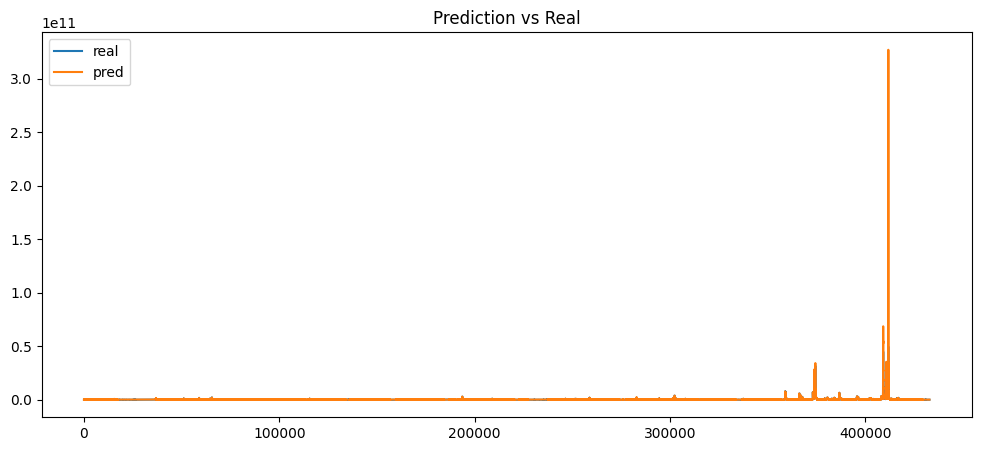

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="real")
plt.plot(lgmb_pred, label="pred")
plt.legend()
plt.title("Prediction vs Real")
plt.show()

In [74]:
import pandas as pd

lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(lgbm_importance.head(20))

base_fee_per_gas      2034
last_eth_price        1771
hour                  1509
eth_volatility_1h     1433
minute_sin            1273
base_fee_lag_300      1253
minute_cos            1131
base_fee_ma_5          999
eth_return_1h          971
utilization_ma_20      850
hour_cos               844
utilization_ma_5       819
hour_sin               792
utilization_ma_50      791
block_utilization      782
base_fee_change_50     704
base_fee_lag_1         648
eth_return_10m         585
base_fee_vol_20        546
base_fee_change_10     529
dtype: int32


In [77]:
baseline_pred = X_test["base_fee_lag_1"]

mae_baseline = mean_absolute_error(y_test, baseline_pred)

print("Baseline MAE:", mae_baseline)
print("Model MAE:", lbgm_mae)

Baseline MAE: 11099575.663593117
Model MAE: 104062496.49361573


In [52]:
from xgboost import XGBRegressor

In [53]:
model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",   
    early_stopping_rounds=50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [54]:

# ===== Метрики =====
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 188739150.6422269
RMSE: 1271227925.0997415


In [50]:
328580466 / 10**18

3.28580466e-10

In [55]:
df[['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'target_next_block', 'target_10m',
       'target_1h', 'target_1d', 'target_1w']]

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,target_next_block,target_10m,target_1h,target_1d,target_1w
300,21526191,65508,30000000,10068041,169,4244822344,3356.479770,4.070362e+09,3.798844e+09,3.112347e+09,3.423671e+10,6.068384e+09
301,21526192,109474,30000000,21034762,253,4070361596,3356.479770,4.275059e+09,3.914521e+09,3.045856e+09,3.385476e+10,5.942056e+09
302,21526193,123433,30029295,19159565,266,4275058791,3356.479770,4.422579e+09,3.961487e+09,3.014190e+09,3.376894e+10,5.806226e+09
303,21526194,71519,30000000,11224650,161,4422579476,3356.479770,4.283440e+09,4.003519e+09,3.105131e+09,3.312228e+10,5.867348e+09
304,21526195,120064,30000000,18064373,199,4283439598,3356.479770,4.392823e+09,3.852421e+09,3.201450e+09,3.332379e+10,5.999613e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
2889358,24415249,91980,60000000,30758469,52,72479416,2124.765385,7.270847e+07,7.699298e+07,4.707488e+07,5.516012e+07,3.217454e+07
2889359,24415250,59514,60000000,10274534,8,72708471,2124.765385,6.673260e+07,7.520740e+07,4.301503e+07,5.163141e+07,2.948522e+07
2889360,24415251,294332,60000000,57395709,519,66732603,2122.551926,7.435005e+07,7.735471e+07,4.340148e+07,4.929392e+07,3.298455e+07
2889361,24415252,99446,60000000,19699521,62,74350048,2122.551926,7.115904e+07,7.847975e+07,4.529810e+07,5.289519e+07,3.419961e+07


In [61]:
print(df.loc[70000:70301].to_string())

         height    size  gas_limit  gas_used  transaction_count  base_fee_per_gas  last_eth_price  target_next_block    target_10m     target_1h     target_1d     target_1w  block_utilization  gas_pressure  tx_per_gas  base_fee_lag_1  base_fee_lag_2  base_fee_lag_3  base_fee_lag_5  base_fee_lag_10  base_fee_lag_20  base_fee_lag_50  base_fee_lag_100  base_fee_lag_300  utilization_lag_1  utilization_lag_2  utilization_lag_3  utilization_lag_5  utilization_lag_10  utilization_lag_20  base_fee_ma_5  base_fee_ma_20  base_fee_ma_50  base_fee_ma_300  base_fee_vol_20  base_fee_vol_50  base_fee_vol_300  utilization_ma_5  utilization_ma_20  utilization_ma_50  eth_return_1m  eth_return_10m  eth_return_1h  eth_volatility_1h  hour  day_of_week  hour_sin      hour_cos  base_fee_change_1  base_fee_change_10  base_fee_change_50  gas_used_change  tx_change    minute_sin    minute_cos  is_weekend
70000  21595891   86993   30000000  17564451                220        7372794594     3293.534612       7.53

In [52]:
df.columns

Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'target_next_block', 'target_10m',
       'target_1h', 'target_1d', 'target_1w', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'base_fee_lag_1', 'base_fee_lag_2',
       'base_fee_lag_3', 'base_fee_lag_5', 'base_fee_lag_10',
       'base_fee_lag_20', 'base_fee_lag_50', 'base_fee_lag_100',
       'base_fee_lag_300', 'utilization_lag_1', 'utilization_lag_2',
       'utilization_lag_3', 'utilization_lag_5', 'utilization_lag_10',
       'utilization_lag_20', 'base_fee_ma_5', 'base_fee_ma_20',
       'base_fee_ma_50', 'base_fee_ma_300', 'base_fee_vol_20',
       'base_fee_vol_50', 'base_fee_vol_300', 'utilization_ma_5',
       'utilization_ma_20', 'utilization_ma_50', 'eth_return_1m',
       'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h', 'hour',
       'day_of_week', 'hour_sin', 'hour_cos', 'base_fee_change_1',
       'base_fee_change_10', 'base_fee_change

In [57]:
# Получаем важность признаков
xgboost_importance = model.feature_importances_

# Создаём DataFrame для удобства
xgboost_importance_df = pd.DataFrame({
    'feature': list(X_train.columns),
    'importance': xgboost_importance
}).sort_values('importance', ascending=False)

xgboost_importance_df

,feature,importance
4,base_fee_per_gas,0.407271
24,base_fee_ma_5,0.260381
38,hour,0.082843
9,base_fee_lag_1,0.077328
47,minute_sin,0.031459
36,eth_return_1h,0.030524
11,base_fee_lag_3,0.018062
10,base_fee_lag_2,0.017667
41,hour_cos,0.015710
5,last_eth_price,0.008068


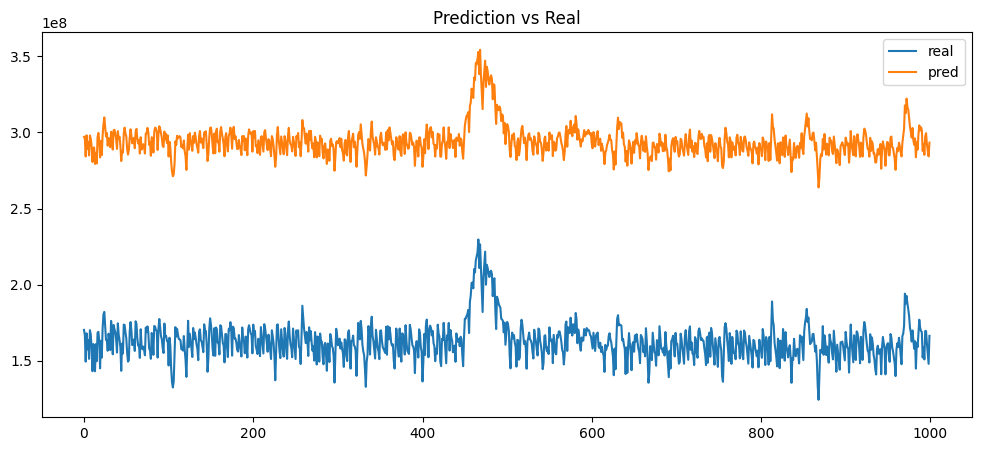

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:1000], label="real")
plt.plot(pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real")
plt.show()

In [86]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

expected_base_fee_next    2187
minute_sin                1072
minute_cos                 988
hour                       982
eth_volatility_1h          861
base_fee_lag_300           736
last_eth_price             726
base_fee_per_gas           472
eth_return_1h              471
utilization_ma_20          456
utilization_ma_50          431
utilization_ma_5           380
height                     367
hour_cos                   345
base_fee_lag_100           276
hour_sin                   209
gas_limit                  202
base_fee_vol_20            189
base_fee_vol_300           182
eth_return_10m             174
dtype: int32


In [87]:
baseline_pred = X_test["base_fee_lag_1"]

mae_baseline = mean_absolute_error(y_test, baseline_pred)

print("Baseline MAE:", mae_baseline)
print("Model MAE:", mae)

Baseline MAE: 11099575.663593117
Model MAE: 417921629.0773042


In [88]:
417921629.0773042 / 10**9

0.4179216290773042

In [89]:
11099575 / 10**9

0.011099575

### Модель для прогнозирования газа через день

In [101]:
target = "target_1d"

X_train = train.drop(columns=targets)
y_train = train[target]

X_val = val.drop(columns=targets)
y_val = val[target]

X_test = test.drop(columns=targets)
y_test = test[target]

In [102]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=30,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций (можно убрать)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11640
[LightGBM] [Info] Number of data points in the train set: 2019884, number of used features: 52
[LightGBM] [Info] Start training from score 2462978512.062000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.46151e+10	valid_0's l2: 2.136e+20
Early stopping, best iteration is:
[1]	valid_0's rmse: 2.62049e+09	valid_0's l2: 6.86698e+18


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,30
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2505205551.4637938
RMSE: 2709415938.1473794


In [109]:
2505205551.4637938 / 10**9

2.505205551463794

In [104]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [105]:
def evaluate(y_true, y_pred, name="set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} results:")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")

    return mae, rmse

In [106]:
train_mae, train_rmse = evaluate(y_train, train_pred, "TRAIN")
test_mae, test_rmse = evaluate(y_test, test_pred, "TEST")


TRAIN results:
MAE : 2,706,528,566.88
RMSE: 7,910,979,539.60

TEST results:
MAE : 2,505,205,551.46
RMSE: 2,709,415,938.15


In [107]:
overfit_ratio = test_mae / train_mae

print("\nOverfit ratio (test/train):", overfit_ratio)


Overfit ratio (test/train): 0.9256157803484445


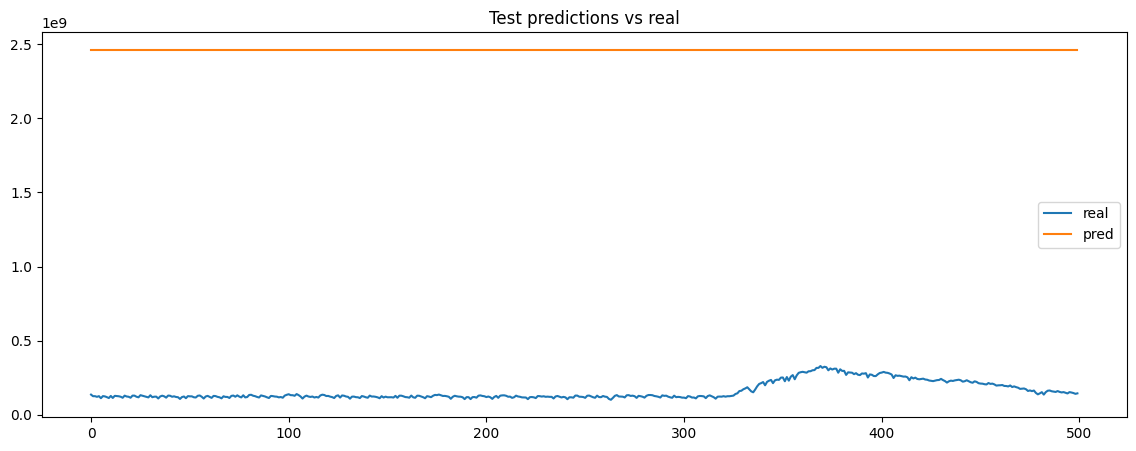

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(y_test.values[:500], label="real")
plt.plot(test_pred[:500], label="pred")

plt.title("Test predictions vs real")
plt.legend()
plt.show()